In [7]:
   import socket, os, requests
   import psycopg2
   import pandas as pd
   import matplotlib.pyplot as plt

   print("Librerias listas")

Librerias listas


In [8]:
servicios = ["nginx", "joomla", "database", "grafana"]
for nombre in servicios:
    try:
        ip = socket.gethostbyname(nombre)
        print(f"{nombre:10s} -> {ip}")
    except socket.gaierror:
        print(f"{nombre:10s} -> no resuelve desde este contenedor")

nginx      -> 172.28.10.5
joomla     -> 172.28.10.3
database   -> 172.28.20.2
grafana    -> 172.28.10.4


In [9]:
EDGE = os.environ.get("EDGE_URL", "http://nginx")
rutas = ["/", "/healthz", "/administrator/", "/ruta-inexistente"]

for _ in range(10):
    for r in rutas:
        resp = requests.get(EDGE + r, timeout=5)
        print(f"{resp.status_code}  {r}")

200  /
200  /healthz
200  /administrator/
404  /ruta-inexistente
200  /
200  /healthz
200  /administrator/
404  /ruta-inexistente
200  /
200  /healthz
200  /administrator/
404  /ruta-inexistente
200  /
200  /healthz
200  /administrator/
404  /ruta-inexistente
200  /
200  /healthz
200  /administrator/
404  /ruta-inexistente
200  /
200  /healthz
200  /administrator/
404  /ruta-inexistente
200  /
200  /healthz
200  /administrator/
404  /ruta-inexistente
200  /
200  /healthz
200  /administrator/
404  /ruta-inexistente
200  /
200  /healthz
200  /administrator/
404  /ruta-inexistente
200  /
200  /healthz
200  /administrator/
404  /ruta-inexistente


In [10]:
conn = psycopg2.connect(
    host=os.environ["POSTGRES_HOST"],
    port=os.environ["POSTGRES_PORT"],
    dbname=os.environ["POSTGRES_DB"],
    user=os.environ["POSTGRES_USER"],
    password=os.environ["POSTGRES_PASSWORD"],
)
print("Conectado a PostgreSQL:", conn.get_dsn_parameters()["host"])

Conectado a PostgreSQL: database


(1261, 4) filas


/tmp/ipykernel_1807/4078519640.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(


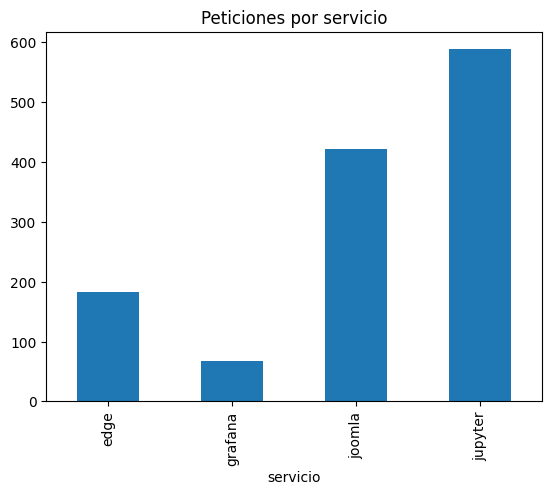

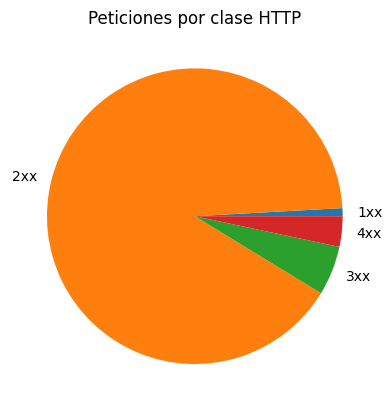

In [11]:
df = pd.read_sql(
    "SELECT time, servicio, status, clase_status FROM observabilidad.trafico ORDER BY time",
    conn,
)
print(df.shape, "filas")

df.groupby("servicio").size().plot(kind="bar", title="Peticiones por servicio")
plt.show()

df.groupby("clase_status").size().plot(kind="pie", title="Peticiones por clase HTTP")
plt.show()

In [12]:
actividad = pd.read_sql("SELECT * FROM observabilidad.actividad_bd", conn)
actividad

/tmp/ipykernel_1807/3265489629.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  actividad = pd.read_sql("SELECT * FROM observabilidad.actividad_bd", conn)


,time,base_datos,conexiones_activas,transacciones_commit,transacciones_rollback,bloques_disco,bloques_cache,cache_hit_pct,tup_returned,tup_fetched,tup_inserted,tup_updated,tup_deleted,bytes_totales
0,2026-09-26 03:47:07.116003+00:00,joomladb,1,12695,1,600,823168,99.93,731911,487358,7357,1582,126,15096855
